# Linear support vector machines

A support vector machine chooses a linear boundary while balancing classification errors against the size of the weight vector. The geometry is expressed through the signed margin rather than through probability estimates.


## Signed margin and hinge loss

For labels `y` in `{-1, +1}`, the signed margin of an observation is

```text
y (wᵀx + b)
```

A margin of at least one incurs no hinge loss. A point with a smaller margin is either inside the margin or on the wrong side of the boundary.


## Soft-margin objective

The primal objective used here is

```text
1/2 ||w||² + C mean(max(0, 1 - y(wᵀx + b)))
```

The first term prefers a smaller weight vector and therefore a wider margin. `C` controls how strongly margin violations are penalized.


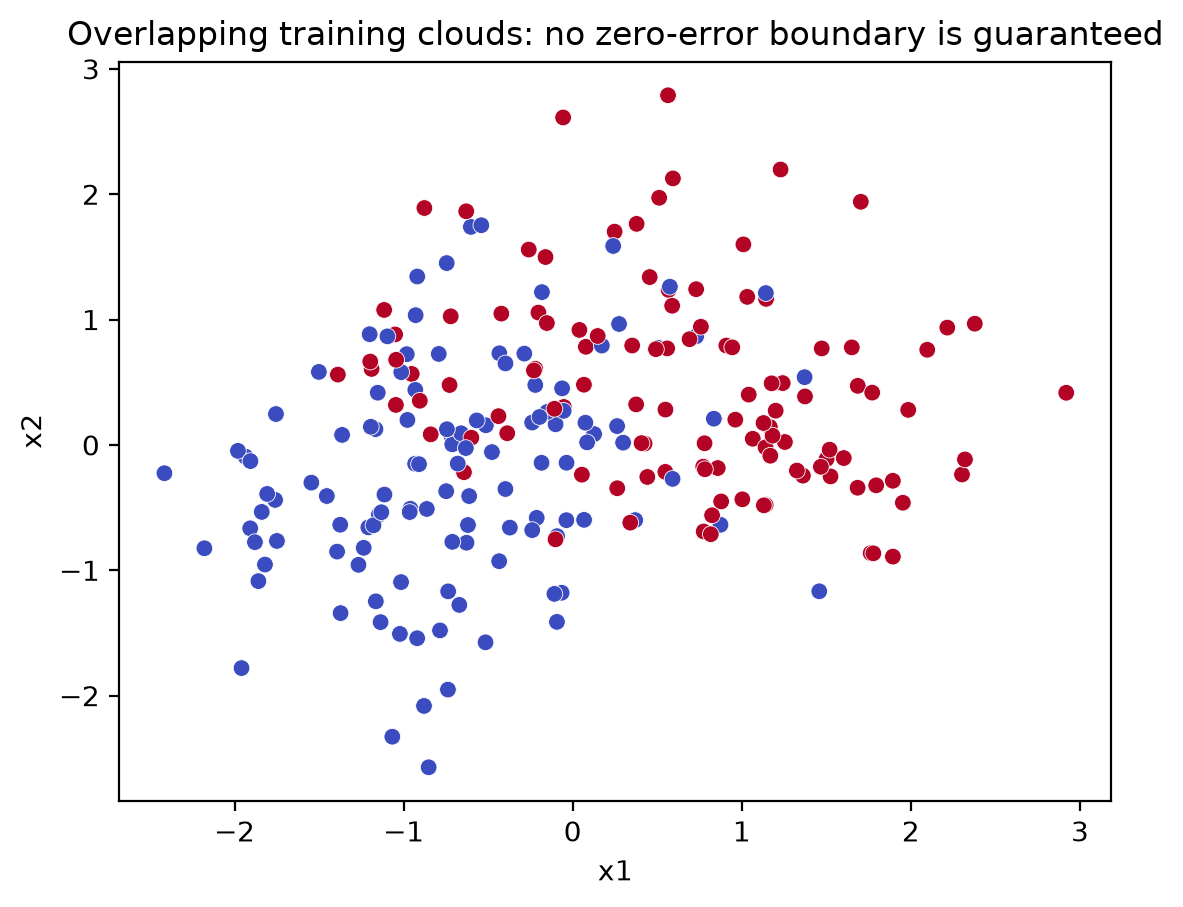

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(9)
negative = rng.multivariate_normal(mean=(-0.7, -0.4), cov=[[0.75, 0.25], [0.25, 0.65]], size=160)
positive = rng.multivariate_normal(mean=(0.7, 0.4), cov=[[0.75, -0.20], [-0.20, 0.65]], size=160)
X = np.vstack([negative, positive])
y = np.r_[-np.ones(len(negative)), np.ones(len(positive))]
order = rng.permutation(len(y))
train_idx, test_idx = order[:230], order[230:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolor='white', linewidth=0.3)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Overlapping training clouds: no zero-error boundary is guaranteed')
plt.show()


train accuracy: 0.8130434782608695
test accuracy: 0.8111111111111111
points inside or on margin: 202


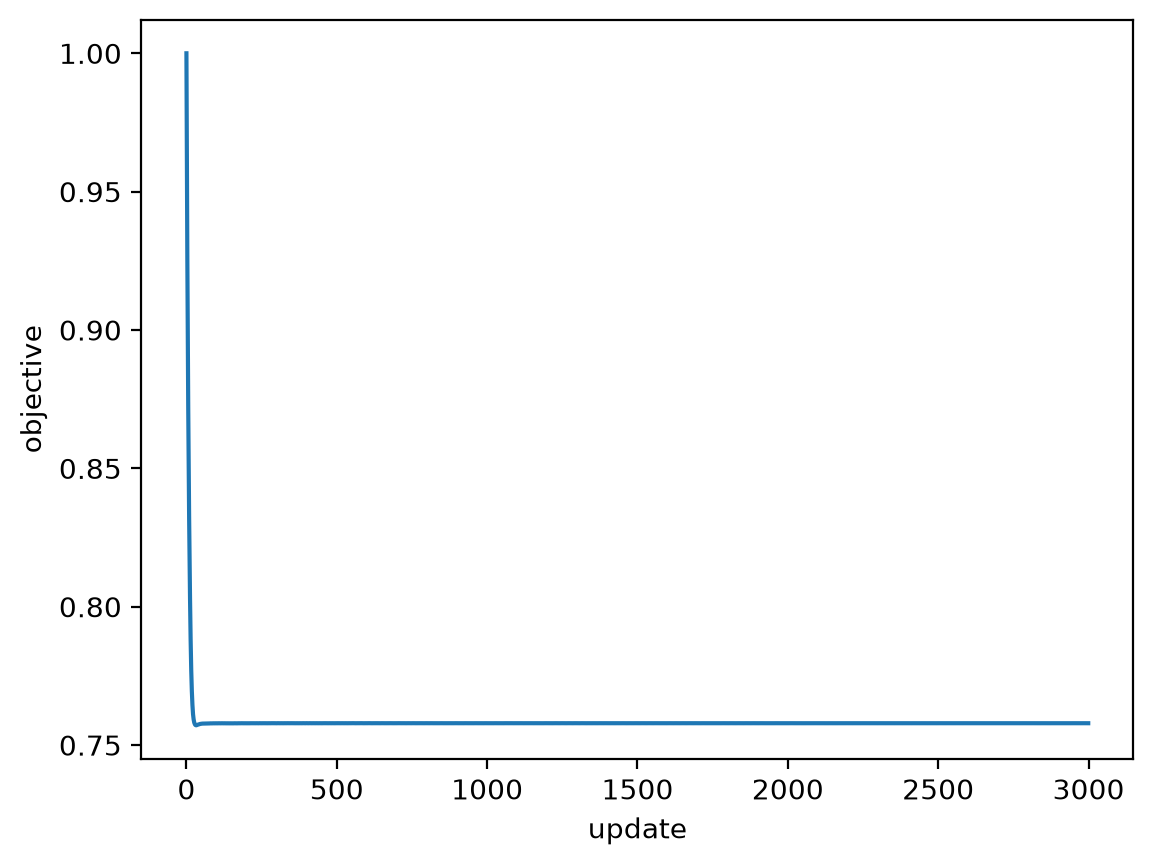

In [2]:
def fit_linear_svm(X, y, C=1.0, steps=3000):
    w = np.zeros(X.shape[1])
    b = 0.0
    losses = []

    for step in range(steps):
        margins = y * (X @ w + b)
        active = margins < 1
        hinge = np.maximum(0, 1 - margins)
        losses.append(0.5 * w @ w + C * hinge.mean())

        grad_w = w.copy()
        grad_b = 0.0
        if np.any(active):
            grad_w -= C * np.mean(X[active] * y[active, None], axis=0)
            grad_b = -C * np.mean(y[active])

        rate = 0.05 / (1 + 0.001 * step)
        w -= rate * grad_w
        b -= rate * grad_b

    return w, b, np.array(losses)

def accuracy(X, y, w, b):
    return np.mean(np.sign(X @ w + b) == y)

w, b, losses = fit_linear_svm(X_train, y_train, C=1.0)
train_margins = y_train * (X_train @ w + b)
support_like = train_margins <= 1 + 1e-6

print('train accuracy:', accuracy(X_train, y_train, w, b))
print('test accuracy:', accuracy(X_test, y_test, w, b))
print('points inside or on margin:', support_like.sum())

plt.plot(losses)
plt.xlabel('update')
plt.ylabel('objective')
plt.show()

## Subgradient implementation

The code fits the linear primal objective with full-batch subgradient descent. This exposes which points are active in the hinge-loss term. It is an implementation for understanding the objective, not a replacement for a production SVM solver.


C= 0.1: test accuracy=0.478, margin violations=230
C= 1.0: test accuracy=0.811, margin violations=202


C=10.0: test accuracy=0.822, margin violations=121


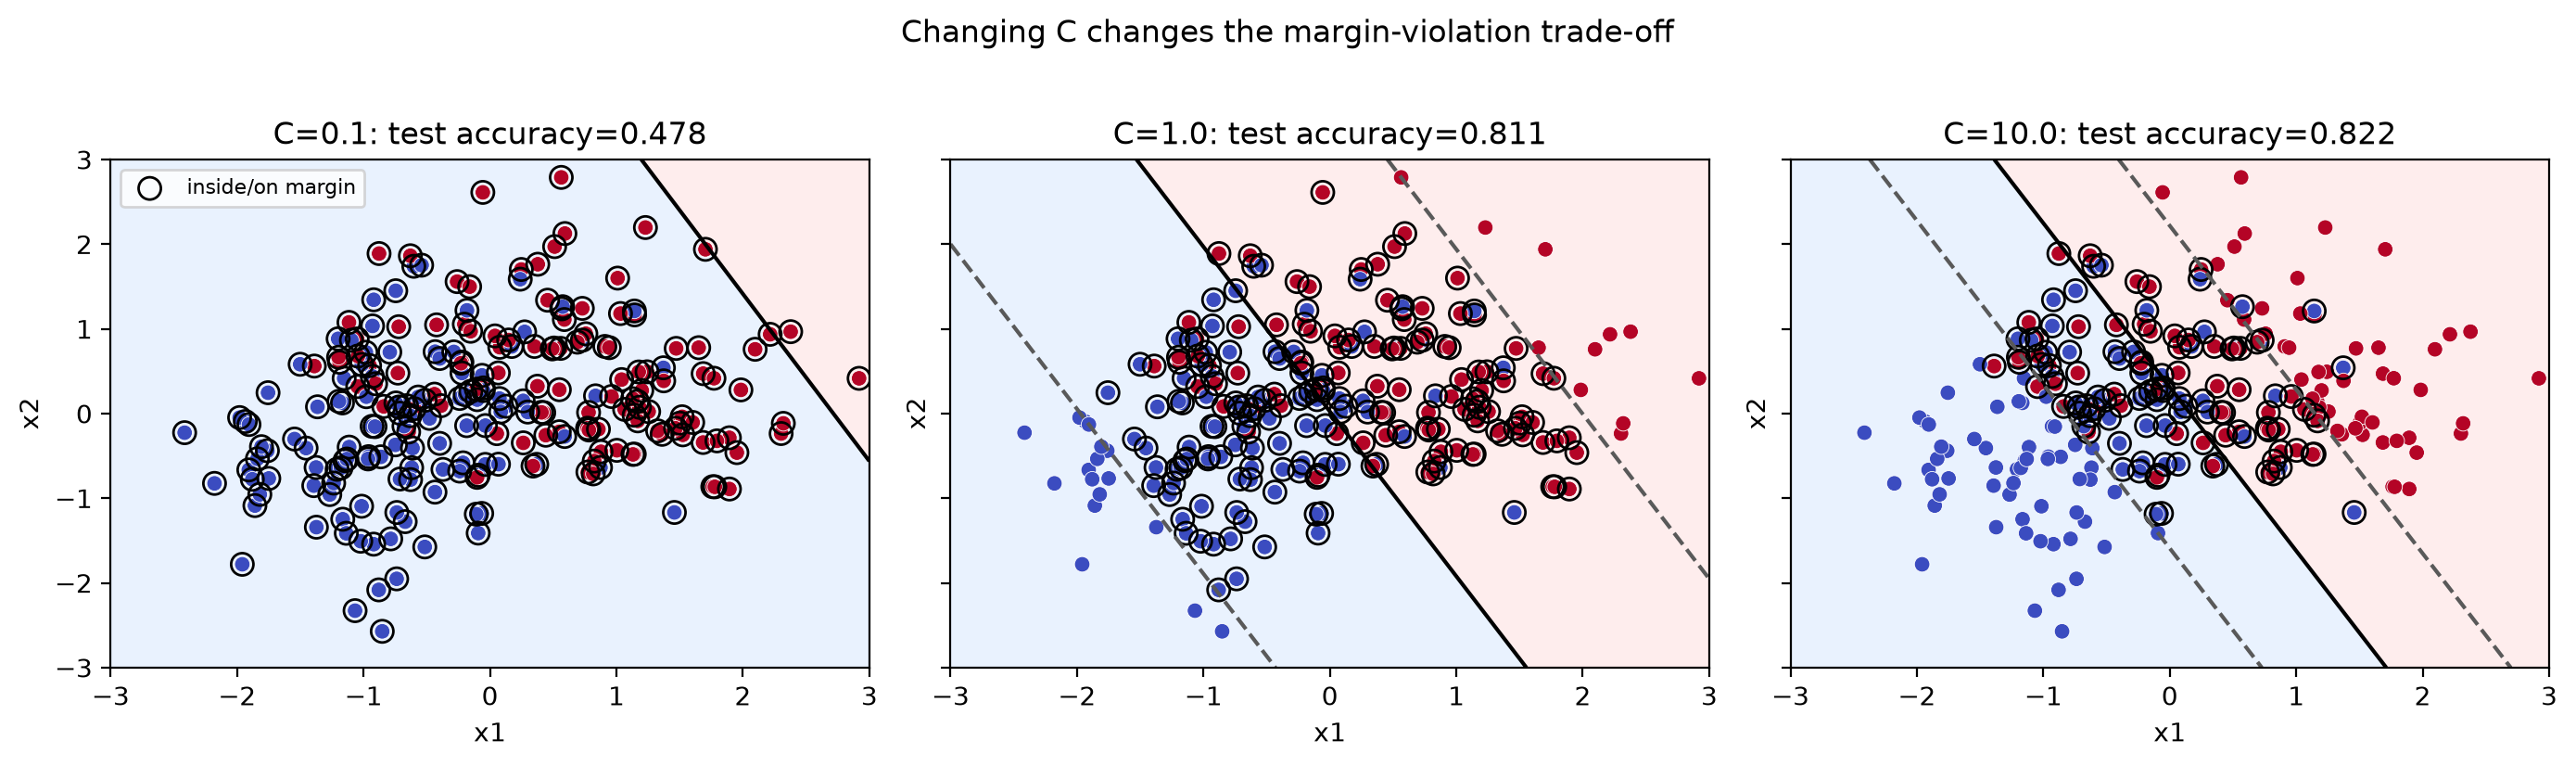

In [3]:
def draw_boundary(ax, w, b, C):
    grid_x, grid_y = np.meshgrid(np.linspace(-3, 3, 240), np.linspace(-3, 3, 240))
    score = w[0] * grid_x + w[1] * grid_y + b
    ax.contourf(grid_x, grid_y, score, levels=[-10, 0, 10], colors=['#dbeafe', '#fee2e2'], alpha=0.6)
    ax.contour(grid_x, grid_y, score, levels=[-1, 0, 1], colors=['0.35', 'black', '0.35'], linestyles=['--', '-', '--'])
    margins = y_train * (X_train @ w + b)
    active = margins <= 1 + 1e-6
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolor='white', linewidth=0.3)
    ax.scatter(X_train[active, 0], X_train[active, 1], s=75, facecolors='none', edgecolors='black', label='inside/on margin')
    ax.set(title=f'C={C}: test accuracy={accuracy(X_test, y_test, w, b):.3f}', xlabel='x1', ylabel='x2', xlim=(-3, 3), ylim=(-3, 3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for ax, C in zip(axes, [0.1, 1.0, 10.0]):
    w_c, b_c, _ = fit_linear_svm(X_train, y_train, C=C)
    draw_boundary(ax, w_c, b_c, C)
    margins = y_train * (X_train @ w_c + b_c)
    print(f'C={C:>4}: test accuracy={accuracy(X_test, y_test, w_c, b_c):.3f}, margin violations={(margins < 1).sum()}')
axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Changing C changes the margin-violation trade-off', y=1.02)
fig.tight_layout()
plt.show()


## Changing `C`

The two synthetic classes overlap, so the model has to trade off a wide margin against training violations. A small `C` gives the regularization term more influence. A large `C` places more pressure on the observed labels. The boundary plots show the margin and the active points for each value.
